In [2]:
import numpy as np 
import sklearn
import matplotlib.pyplot as plt
import os
import copy
import sys 
sys.path.append("..")
import scipy

In [3]:
import src.model_systems as model_systems
import src.helpers as helpers
import src.potentials as potentials
import src.diffusion_map as diffusion_map
from two_cluster_helpers import *

# Spectral clustering

In [4]:
clusters_experiment = np.load('gaussian_clusters/clusters_experiment.npz', allow_pickle=True)
dataset = clusters_experiment['dataset']
labels = clusters_experiment['labels']
boolean_vector = clusters_experiment['boolean_vector']
dmap = clusters_experiment['dmap']
nmap = clusters_experiment['nmap']

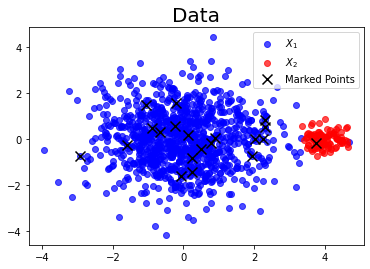

In [6]:
# Plot the dataset
plt.scatter(dataset[:1000, 0], dataset[:1000, 1], label = '$X_1$', color = 'blue', alpha=0.7)
plt.scatter(dataset[1000:, 0], dataset[1000:, 1], label = '$X_2$', color = 'red', alpha=0.7)
plt.scatter(dataset[~boolean_vector, 0], dataset[~boolean_vector, 1], color='black', alpha=1.0, s=100, marker='x', label='Marked Points')
plt.legend()
plt.title("Data", fontsize=20)
plt.savefig('gaussian_clusters.png')

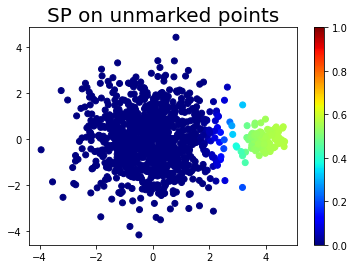

In [167]:
plt.Figure(figsize=(12,12))
plt.scatter(dataset[boolean_vector, 0], dataset[boolean_vector, 1], c=dmap[:,0], cmap='jet', vmin=0, vmax=1.0)
plt.title('SP on unmarked points', fontsize=20)
plt.colorbar()
plt.savefig("SP vector")

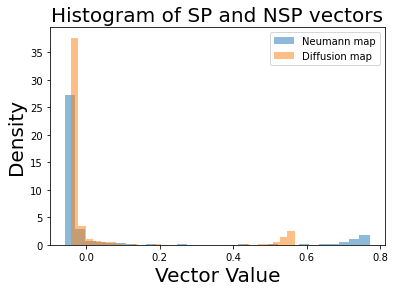

In [168]:
plt.hist(nmap[:,0], bins=30, alpha=0.5, label='Neumann map', density=True)
plt.hist(dmap[:,0], bins=30, alpha=0.5, label='Diffusion map', density=True)
plt.title('Histogram of SP and NSP vectors', fontsize=20)
plt.xlabel('Vector Value', fontsize=20)
plt.ylabel('Density', fontsize=20)
plt.legend()
plt.savefig('Histogram of SP and NSP vectors')

# Compute over random labels 

In [7]:
from tqdm import tqdm
from scipy.stats import entropy

In [15]:
%%capture
sizes = np.linspace(50,500,10, dtype=int)
stats_mean = np.zeros((10,6), dtype=float)
stats_std = np.zeros((10,6), dtype=float)
for i in tqdm(range(10)): 
    n_marks = sizes[i]
    embeddings = get_embeddings(n_marks)
    dmap_cluster_separation, nmap_cluster_separation = compute_cluster_separator(embeddings, labels)
    dmap_cluster_concentration_0, nmap_cluster_concentration_0 = compute_cluster_concentration(embeddings, labels, 0, setting="std")
    dmap_cluster_concentration_1, nmap_cluster_concentration_1 = compute_cluster_concentration(embeddings, labels, 1, setting="std")
    data_list = [nmap_cluster_separation, dmap_cluster_separation, nmap_cluster_concentration_0, dmap_cluster_concentration_0, nmap_cluster_concentration_1, dmap_cluster_concentration_1]
    for j in range(6): 
        stats_mean[i,j] = np.mean(data_list[j])
        stats_std[i,j] = np.std(data_list[j])
    # gen_plot(data_list, n_marks)

/var/folders/nz/g2p2__rs0zg08cf91bxn73lr0000gn/T/ipykernel_61233/1500828267.py:2: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(sizes/11, stats_mean[:,2], stats_std[:,2], label='Neumann map', \
/var/folders/nz/g2p2__rs0zg08cf91bxn73lr0000gn/T/ipykernel_61233/1500828267.py:4: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(sizes/11, stats_mean[:,3], stats_std[:,3], label='Diffusion map', \


Text(0.5, 1.0, 'Cluster entropy vs number of marked points, \n smaller cluster')

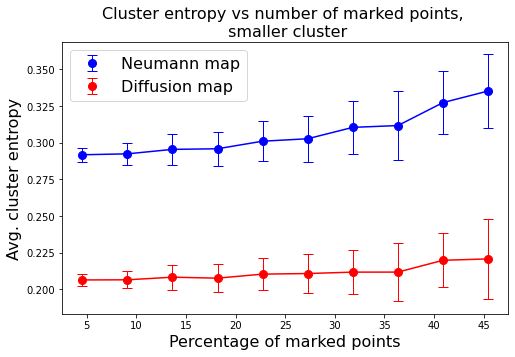

In [17]:
plt.figure(figsize=(8,5))
plt.errorbar(sizes/11, stats_mean[:,2], stats_std[:,2], label='Neumann map', \
            fmt='o', color='blue', ecolor='blue', elinewidth=1, capsize=5, marker='o', markersize=8)
plt.errorbar(sizes/11, stats_mean[:,3], stats_std[:,3], label='Diffusion map', \
            fmt='o', color='red', ecolor='red', elinewidth=1, capsize=5, marker='o', markersize=8)
plt.plot(sizes/11, stats_mean[:,2], color='blue')
plt.plot(sizes/11, stats_mean[:,3], color='red')
plt.legend(fontsize=16)
plt.xlabel('Percentage of marked points', fontsize=16)
plt.ylabel('Avg. cluster entropy', fontsize=16)
plt.title('Cluster entropy vs number of marked points, \n smaller cluster', fontsize=16)
# plt.savefig('Cluster_entropy_smaller_cluster.png')